# 05 `fmiss` Model Progression

This notebook is the counterexample chapter. It shows that the strategy that wins on `fpos` does not simply transfer to `fmiss`, and that the best `fmiss` path stayed more context-first and more conservative.

**Questions answered here**
- Which `fmiss` modeling path actually worked?
- Why did many `fpos`-inspired tricks fail to transfer?
- How broad were the winning `fmiss` gains across families and recordings?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (candidate / "THESIS_BLUEPRINT.md").exists() and (candidate / "src" / "qc_thesis" / "__init__.py").exists():
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("05_fmiss_model_progression")
benchmark = build_benchmark_progress_table("fmiss")
ablation_winners = build_ablation_winner_table("fmiss")
wave_ids = ["fmiss_paired_context", "fmiss_source_reweighted", "fmiss_embed_nommd", "fmiss_reduced_latent", "fmiss_transplanted_fpos"]
waves = build_main_wave_summary("fmiss", wave_ids)
winner_diag = build_prediction_diagnostics("fmiss_reduced_latent", "fmiss")
transplant_diag = build_prediction_diagnostics("fmiss_transplanted_fpos", "fmiss")


## 1. Benchmark ladder

The `fmiss` ladder should be read differently from `fpos`. The winning path is not “add every clever adaptation trick”; it is “keep the backbone stable, use context well, and avoid aggressive unlabeled transfer”.


,label,mae,rmse,r2,bias,calibration_slope,delta_r2_vs_basic_transfer,delta_mae_vs_basic_transfer,notes
0,Dummy paired mean,0.257231,0.290131,-0.003263,0.016547,0.000000,-0.216065,0.063124,Sanity floor
0,Paired-only raw,0.253565,0.346156,-0.428137,-0.132276,0.018134,-0.640939,0.059458,Strict paired-only baseline
0,Hybrid-only XGBoost,0.298049,0.400271,-0.909567,0.216084,0.388333,-1.122368,0.103942,Pure source failure baseline
0,Calibrated hybrid,0.227852,0.266819,0.151484,0.007635,1.910050,-0.061318,0.033744,Simple calibrated transfer
0,Hybrid stack residual,0.194107,0.256997,0.212802,0.005638,0.723260,0.000000,0.000000,First positive transfer baseline
0,Best SSL neural,0.230864,0.325071,-0.259455,-0.100998,0.418224,-0.472257,0.036757,Best SSL comparison
0,Best MMD neural,0.260643,0.309531,-0.141917,0.055433,0.380829,-0.354718,0.066536,Best MMD comparison
0,Paired-only context,0.165854,0.221396,0.415795,-0.014426,0.948846,0.202994,-0.028253,Context-only target baseline
0,Source-reweighted full context,0.162307,0.220090,0.422664,-0.020103,0.941517,0.209862,-0.031801,Source-weighted context-first stack
0,Embed-nommd full context,0.157875,0.213243,0.458027,-0.020380,1.034306,0.245225,-0.036232,Full latent context-first stack


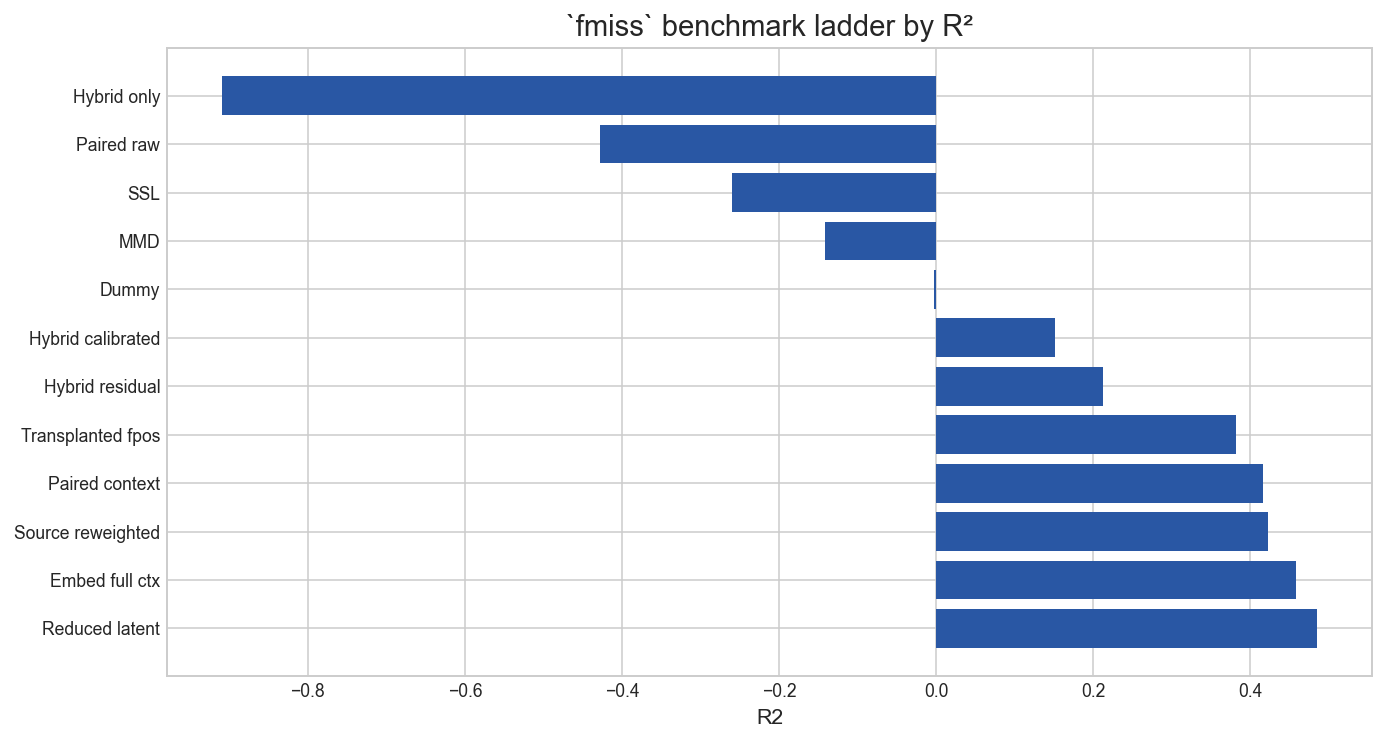

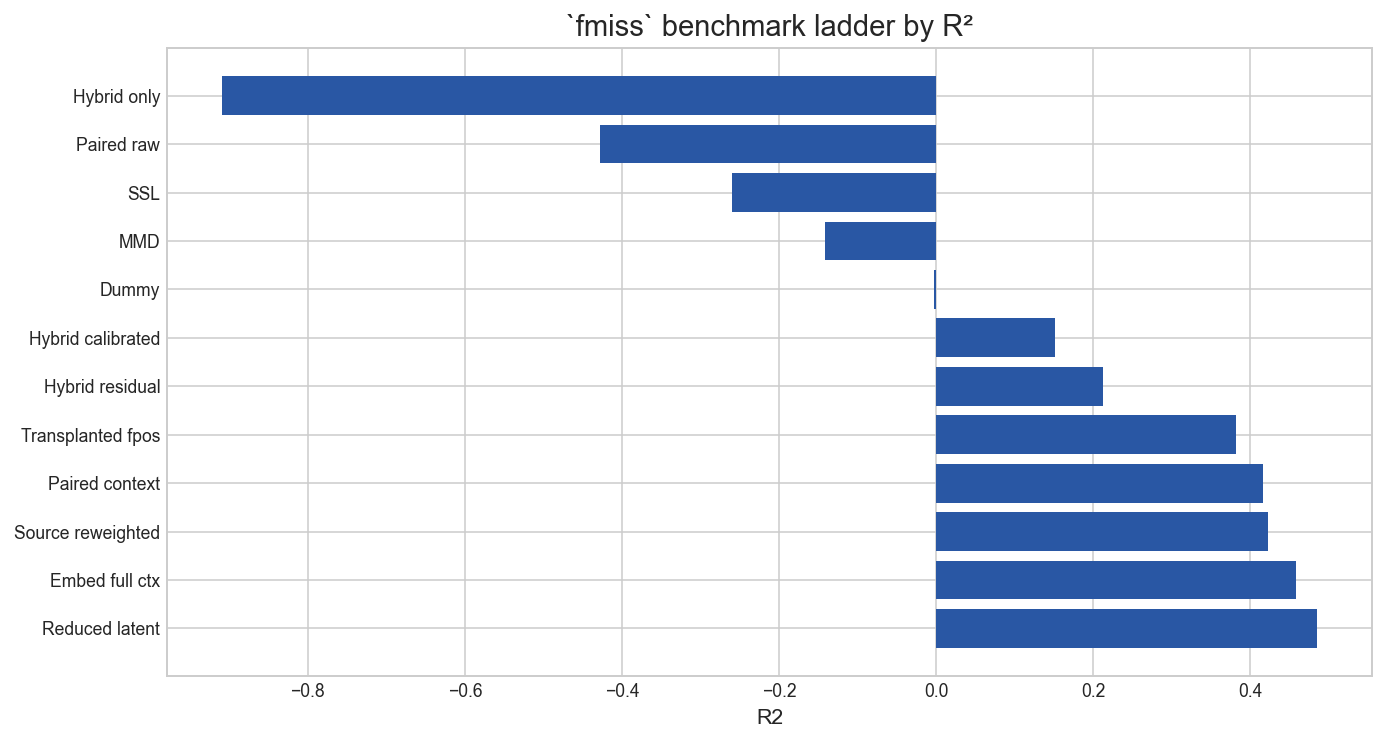

In [2]:
display(benchmark[["label", "mae", "rmse", "r2", "bias", "calibration_slope", "delta_r2_vs_basic_transfer", "delta_mae_vs_basic_transfer", "notes"]])
save_table(benchmark, table_dir, "fmiss_benchmark_ladder")
fig, _ = plot_benchmark_metric(benchmark, metric="r2", title="`fmiss` benchmark ladder by R²")
save_figure(fig, fig_dir, "fmiss_benchmark_r2")
fig


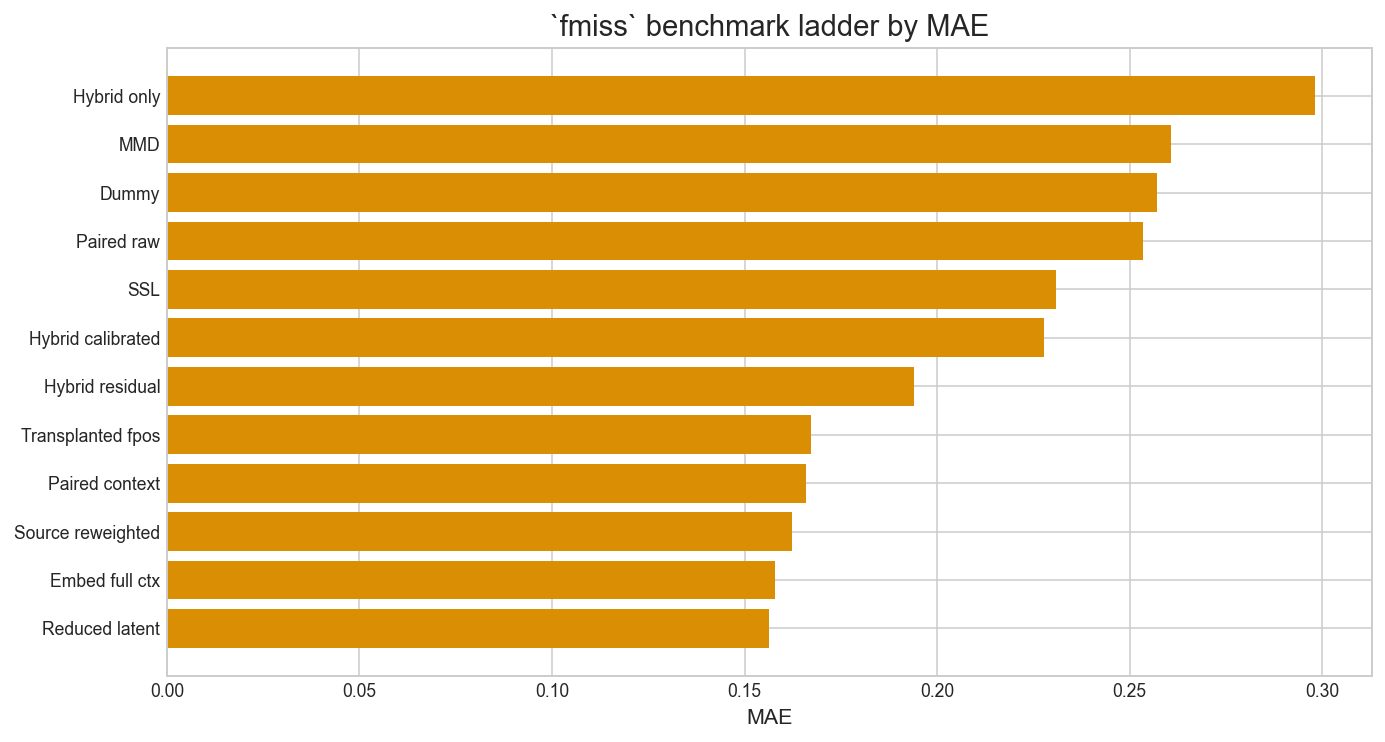

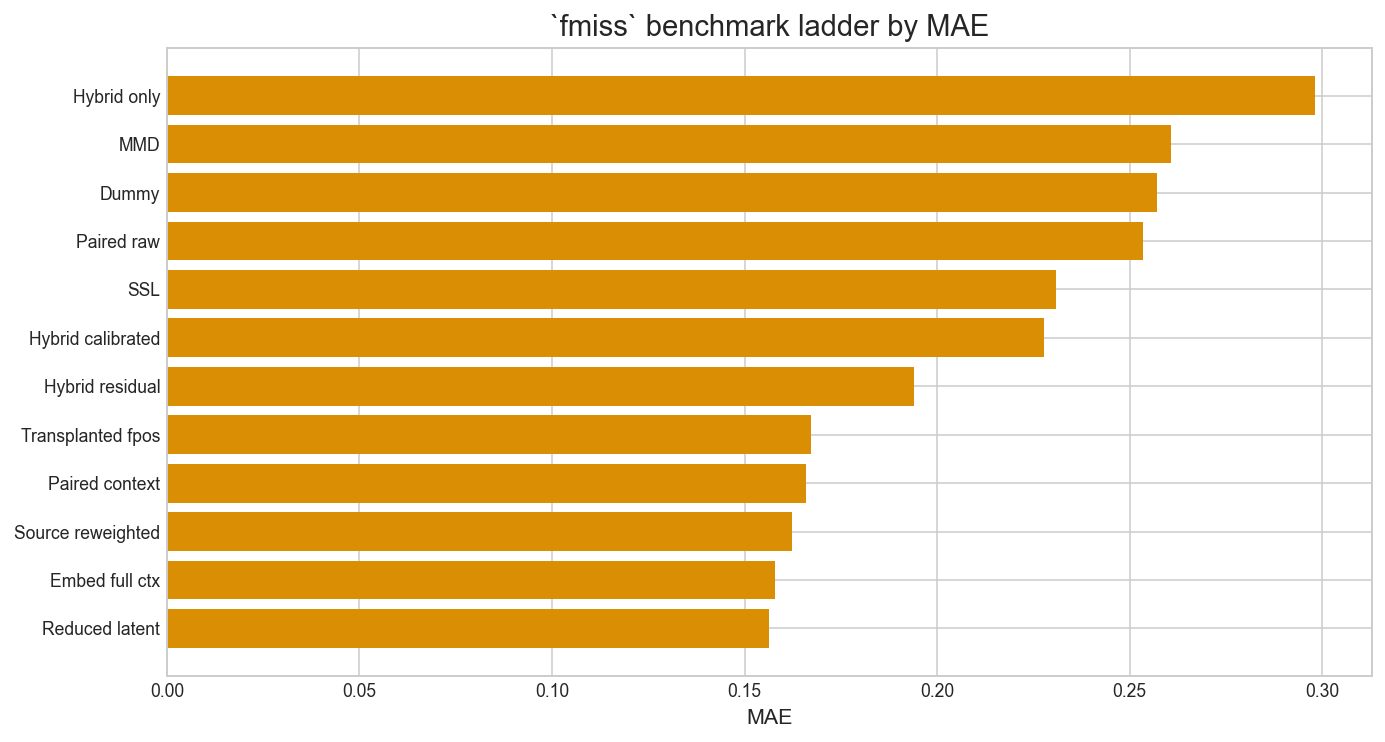

In [3]:
fig, _ = plot_benchmark_metric(benchmark, metric="mae", title="`fmiss` benchmark ladder by MAE")
save_figure(fig, fig_dir, "fmiss_benchmark_mae")
fig


In [4]:
winner_row = benchmark.sort_values("r2", ascending=False).iloc[0]
transplant_row = benchmark.loc[benchmark["recipe_id"] == "fmiss_transplanted_fpos"].iloc[0]
display(Markdown(
    f"""
## Main `fmiss` result

- The best `fmiss` row is **{winner_row['label']}** with **R² {winner_row['r2']:.4f}**.
- The direct transplant of the best `fpos` recipe reaches only **R² {transplant_row['r2']:.4f}**.
- This is direct evidence that `fpos` and `fmiss` are distinct transfer problems, not just different targets on the same pipeline.
"""
))



## Main `fmiss` result

- The best `fmiss` row is **Reduced-latent winner** with **R² 0.4850**.
- The direct transplant of the best `fpos` recipe reaches only **R² 0.3819**.
- This is direct evidence that `fpos` and `fmiss` are distinct transfer problems, not just different targets on the same pipeline.


## 2. `fmiss` ablation story

The ablations here are organized around `fmiss`-specific scientific questions: source target choice, context, transfer family, unlabeled paired use, and representation/filtering.


In [5]:
display(ablation_winners)
save_table(ablation_winners, table_dir, "fmiss_ablation_winners")
for group_name in ["source_target_choice", "context", "transfer_family", "unlabeled_paired_use", "representation_filtering"]:
    bundle = build_ablation_bundle("fmiss", group_name, "recording_disjoint_main")
    display(Markdown(f"### {group_name.replace('_', ' ').title()}"))
    display(bundle["benchmark"][["label", "mae", "r2", "notes"]])
    save_table(bundle["benchmark"], table_dir, f"fmiss_ablation_{group_name}")


,ablation_group,best_label,best_recipe_id,best_r2,best_mae,notes
0,source_target_choice,Hybrid stack residual,fmiss_hybrid_residual,0.212802,0.194107,First positive transfer baseline
1,context,Reduced-latent winner,fmiss_reduced_latent,0.484977,0.156225,Final `fmiss` winner
2,transfer_family,Reduced-latent winner,fmiss_reduced_latent,0.484977,0.156225,Final `fmiss` winner
3,unlabeled_paired_use,Reduced-latent winner,fmiss_reduced_latent,0.484977,0.156225,Final `fmiss` winner
4,representation_filtering,Reduced-latent winner,fmiss_reduced_latent,0.484977,0.156225,Final `fmiss` winner


### Source Target Choice

,label,mae,r2,notes
0,Dummy paired mean,0.257231,-0.003263,Sanity floor
0,Paired-only raw,0.253565,-0.428137,Strict paired-only baseline
0,Hybrid-only XGBoost,0.298049,-0.909567,Pure source failure baseline
0,Calibrated hybrid,0.227852,0.151484,Simple calibrated transfer
0,Hybrid stack residual,0.194107,0.212802,First positive transfer baseline


### Context

,label,mae,r2,notes
0,Paired-only raw,0.253565,-0.428137,Strict paired-only baseline
0,Paired-only context,0.165854,0.415795,Context-only target baseline
0,Source-reweighted full context,0.162307,0.422664,Source-weighted context-first stack
0,Embed-nommd full context,0.157875,0.458027,Full latent context-first stack
0,Reduced-latent winner,0.156225,0.484977,Final `fmiss` winner


...

,label,mae,r2,notes
0,Hybrid-only XGBoost,0.298049,-0.909567,Pure source failure baseline
0,Calibrated hybrid,0.227852,0.151484,Simple calibrated transfer
0,Hybrid stack residual,0.194107,0.212802,First positive transfer baseline
0,Reduced-latent winner,0.156225,0.484977,Final `fmiss` winner


### Unlabeled Paired Use

,label,mae,r2,notes
0,Source-reweighted full context,0.162307,0.422664,Source-weighted context-first stack
0,Reduced-latent winner,0.156225,0.484977,Final `fmiss` winner
0,Transplanted `fpos` waveform recipe,0.167267,0.381920,Failed `fpos` transplant


### Representation Filtering

,label,mae,r2,notes
0,Embed-nommd full context,0.157875,0.458027,Full latent context-first stack
0,Reduced-latent winner,0.156225,0.484977,Final `fmiss` winner
0,Transplanted `fpos` waveform recipe,0.167267,0.381920,Failed `fpos` transplant


## 3. Family and recording behavior

A good `fmiss` story is not just the final best row. The thesis should show where the context-first winner helps and where the transplanted `fpos` recipe clearly misaligns.


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN,21,0.108856,0.148110,0.692144,-0.042099
1,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1,9,0.148694,0.208178,-0.622425,0.012377
2,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH,44,0.218731,0.265620,0.261160,-0.051169
3,fmiss_paired_context,Paired-only context,PAIRED_KAMPFF,6,0.305551,0.339535,-22.347632,0.305551
4,fmiss_paired_context,Paired-only context,PAIRED_MEA64C_YGER,20,0.075185,0.112874,0.836884,-0.012589
5,fmiss_source_reweighted,Source-reweighted full context,PAIRED_BOYDEN,21,0.110262,0.148855,0.689038,-0.047199
6,fmiss_source_reweighted,Source-reweighted full context,PAIRED_CRCNS_HC1,9,0.153837,0.219618,-0.805627,0.020423
7,fmiss_source_reweighted,Source-reweighted full context,PAIRED_ENGLISH,44,0.202627,0.254552,0.321451,-0.072559
8,fmiss_source_reweighted,Source-reweighted full context,PAIRED_KAMPFF,6,0.323230,0.359696,-25.202687,0.321067
9,fmiss_source_reweighted,Source-reweighted full context,PAIRED_MEA64C_YGER,20,0.083782,0.125943,0.796926,0.003161


,recipe_id,label,recording_key,row_count,mae,rmse,r2,bias
0,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,10,0.135238,0.169774,0.641206,-0.009569
1,fmiss_paired_context,Paired-only context,PAIRED_BOYDEN::paired_boyden32c::419_1_8,11,0.084871,0.125203,0.751098,-0.071671
2,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11221_d11221.001,1,0.345440,0.345440,NaN,0.345440
3,fmiss_paired_context,Paired-only context,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,8,0.124101,0.183955,-0.239735,-0.029256
4,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_19...,3,0.408288,0.414709,-39.416858,-0.408288
5,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m139_200114_22...,7,0.246976,0.251133,-1350.831351,0.246976
6,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m14_190326_155432,3,0.214826,0.233023,-85.706775,0.214826
7,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_142...,6,0.177810,0.225834,-0.060998,-0.177810
8,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m15_190315_152...,6,0.151336,0.154035,-3.694701,0.105061
9,fmiss_paired_context,Paired-only context,PAIRED_ENGLISH::paired_english::m26_190524_100...,3,0.442568,0.485076,-7.171202,-0.442568


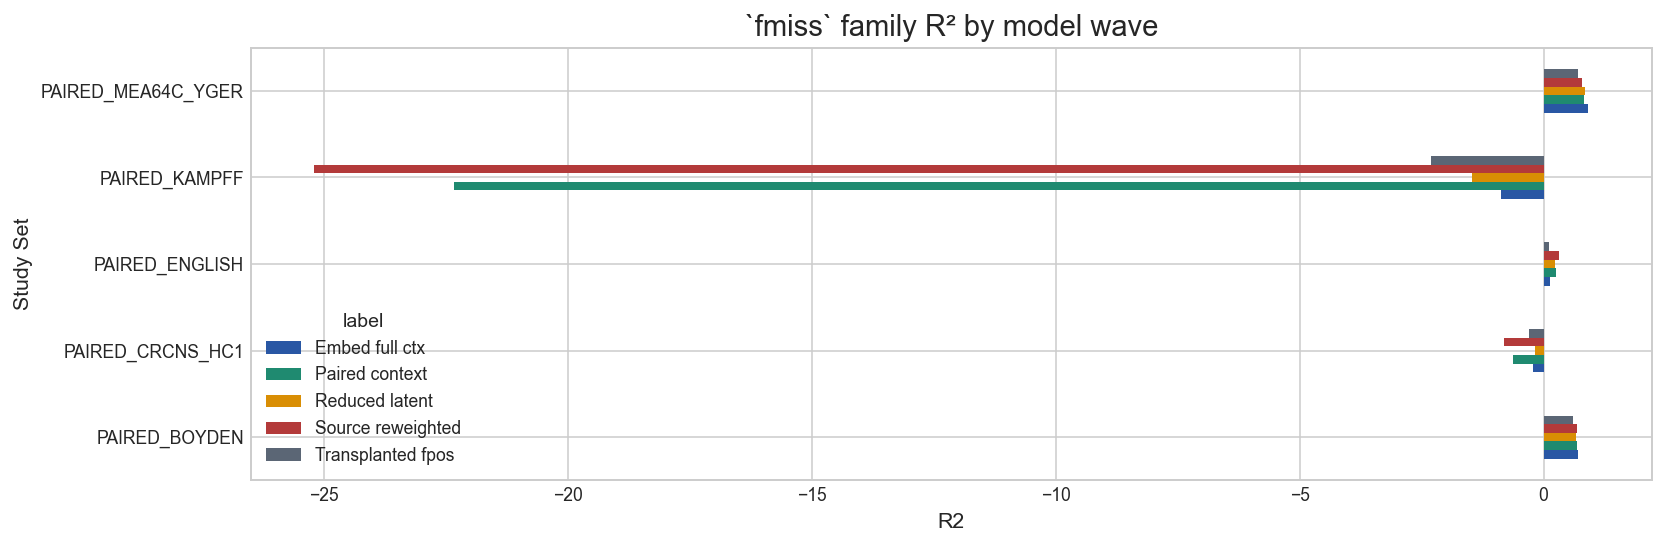

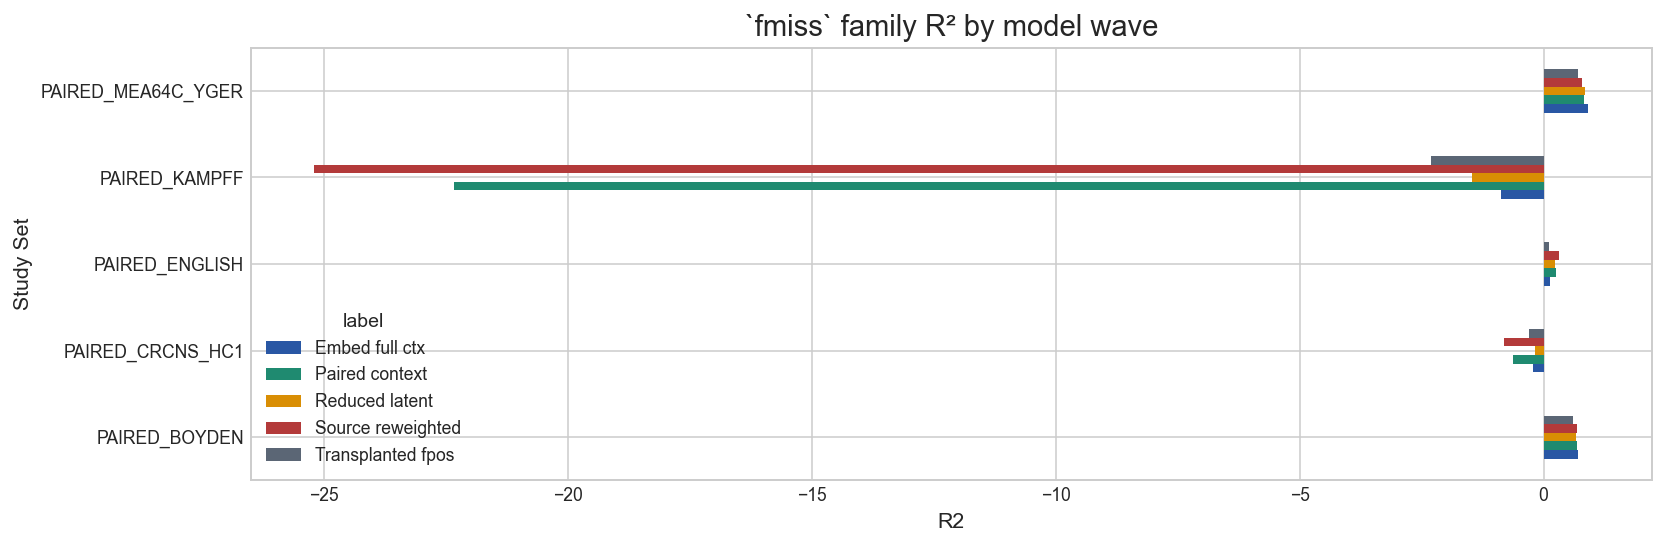

In [6]:
display(waves["family"])
display(waves["recording"].head(20))
save_table(waves["family"], table_dir, "fmiss_family_wave_summary")
save_table(waves["recording"], table_dir, "fmiss_recording_wave_summary")
fig, _, family_pivot = plot_group_metric(waves["family"], group_col="study_set", metric="r2", title="`fmiss` family R² by model wave")
save_figure(fig, fig_dir, "fmiss_family_r2_by_wave")
save_table(family_pivot, table_dir, "fmiss_family_r2_pivot")
fig


,label,recording_key,r2
0,Reduced-latent winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.905922
1,Reduced-latent winner,PAIRED_BOYDEN::paired_boyden32c::419_1_8,0.889561
2,Reduced-latent winner,PAIRED_MEA64C_YGER::paired_mea64c::20170622_pa...,0.827682
3,Reduced-latent winner,PAIRED_BOYDEN::paired_boyden32c::1103_1_1,0.471679
4,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.406085
5,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,0.215776
6,Reduced-latent winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,-0.198838
7,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,-0.397098
8,Reduced-latent winner,PAIRED_KAMPFF::paired_kampff::c14,-1.474106
9,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-2.315934


,label,recording_key,r2
0,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m139_200114_22...,-1525.072468
1,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m14_190326_155432,-184.349395
2,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m139_200114_19...,-32.601440
3,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m57_191105_160026,-11.098808
4,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m26_190524_100...,-2.315934
5,Reduced-latent winner,PAIRED_KAMPFF::paired_kampff::c14,-1.474106
6,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_152...,-0.397098
7,Reduced-latent winner,PAIRED_CRCNS_HC1::paired_crcns::d11222_d11222.002,-0.198838
8,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m57_191105_141906,0.215776
9,Reduced-latent winner,PAIRED_ENGLISH::paired_english::m15_190315_142...,0.406085


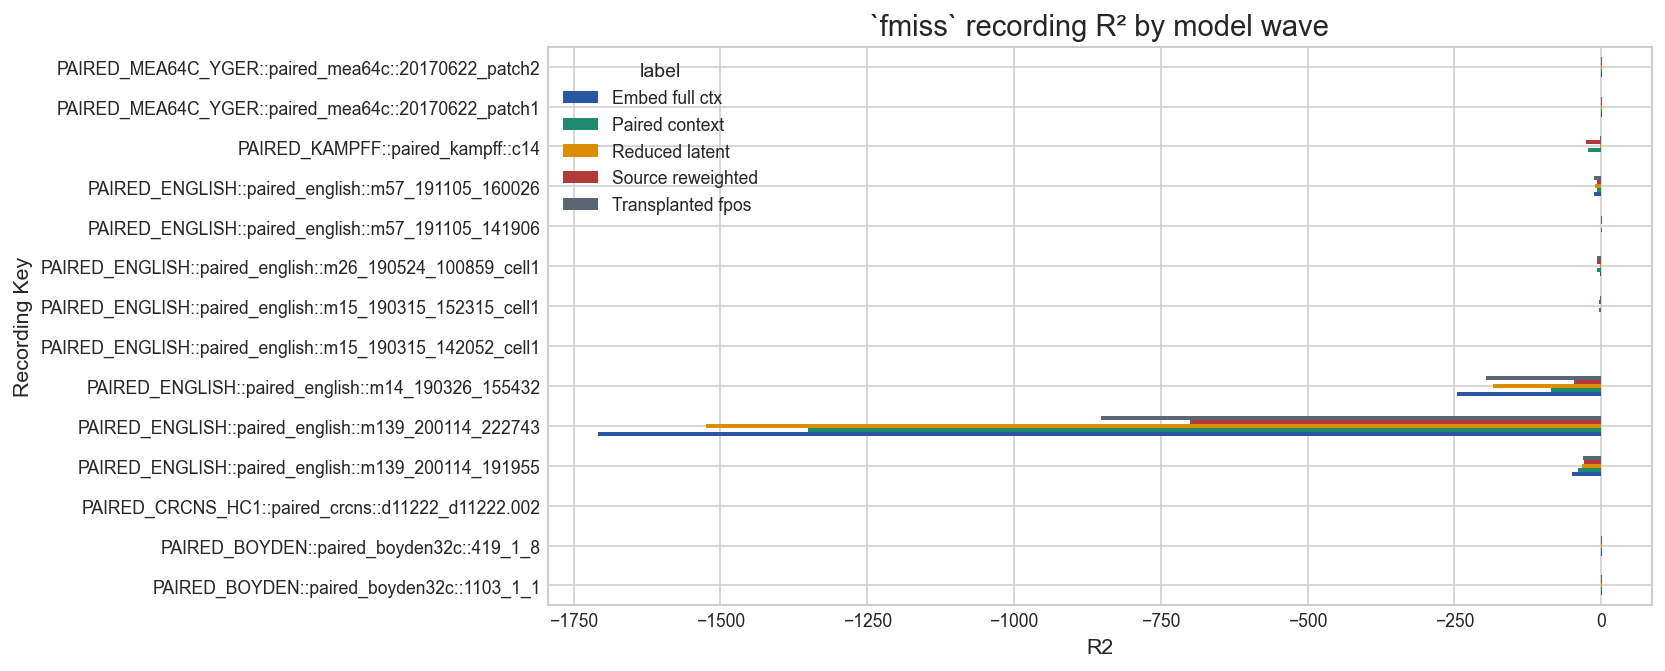

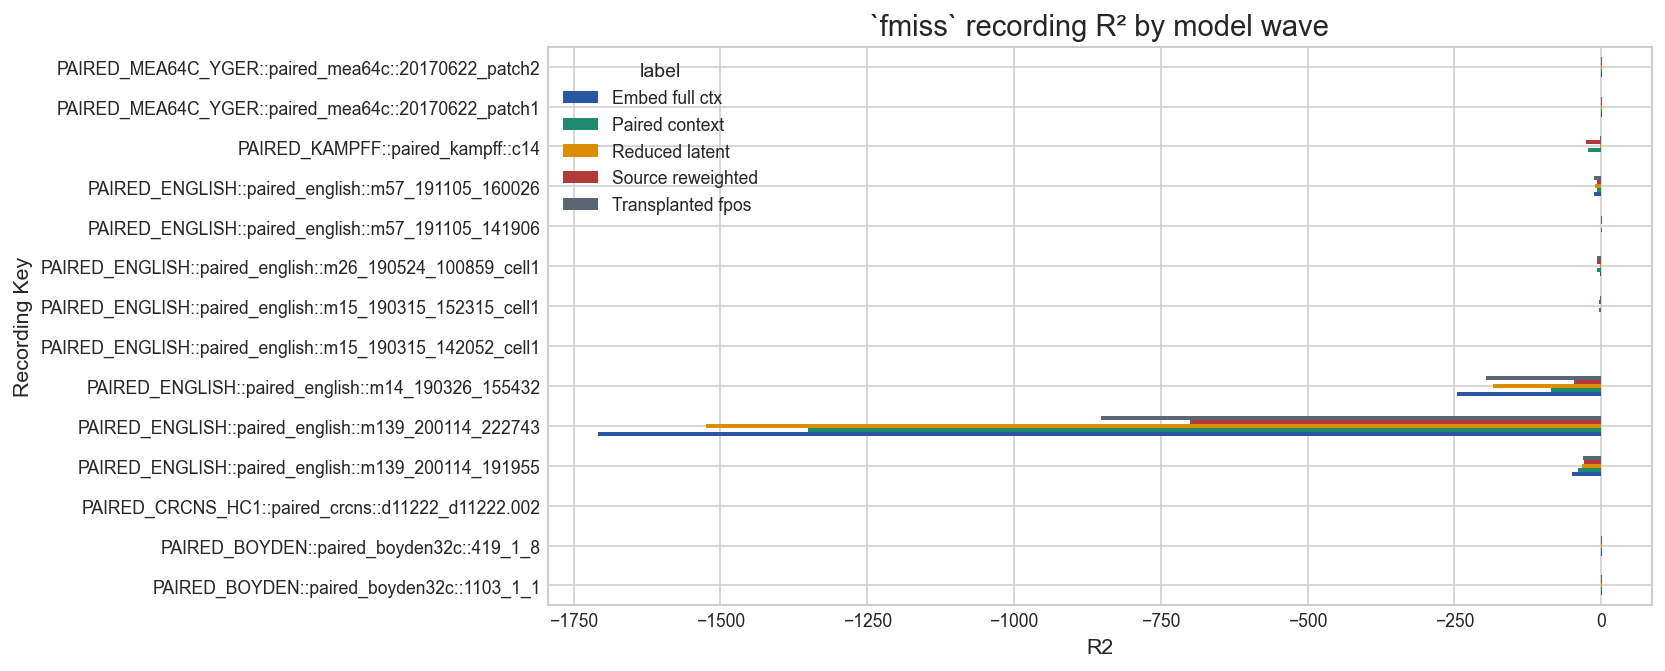

In [7]:
recording_mean = (
    waves["recording"]
    .groupby(["label", "recording_key"], as_index=False)["r2"]
    .mean()
)
top_rec, bottom_rec = build_extreme_groups_table(recording_mean[recording_mean["label"] == "Reduced-latent winner"], group_col="recording_key", metric="r2", top_n=12)
display(top_rec)
display(bottom_rec)
save_table(top_rec, table_dir, "fmiss_top_recordings")
save_table(bottom_rec, table_dir, "fmiss_worst_recordings")
fig, _, rec_pivot = plot_group_metric(waves["recording"], group_col="recording_key", metric="r2", title="`fmiss` recording R² by model wave")
save_figure(fig, fig_dir, "fmiss_top_recording_r2_by_wave")
save_table(rec_pivot, table_dir, "fmiss_recording_r2_pivot")
fig


## 4. Dedicated winner vs transplanted `fpos` recipe

This is the structural comparison that matters most for the asymmetry claim.


,model,mae,bias,correlation
0,Dedicated `fmiss` winner,0.156225,-0.024963,0.705216
1,Transplanted `fpos` recipe,0.167267,-0.054039,0.651060


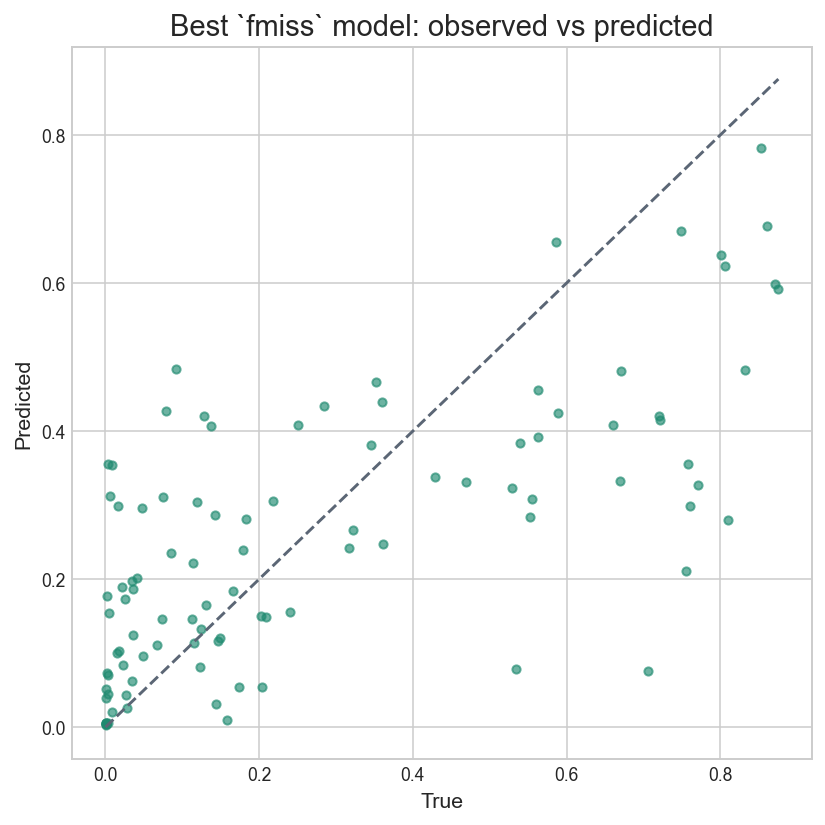

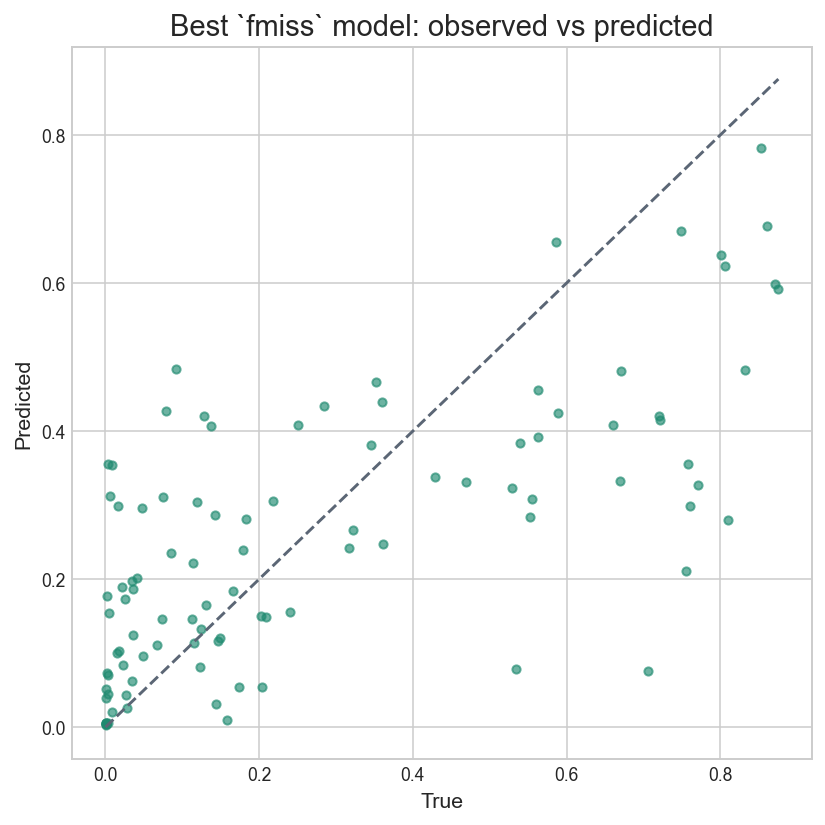

In [8]:
transplant_compare = pd.DataFrame([
    {"model": "Dedicated `fmiss` winner", "mae": winner_diag["mae"], "bias": winner_diag["bias"], "correlation": winner_diag["correlation"]},
    {"model": "Transplanted `fpos` recipe", "mae": transplant_diag["mae"], "bias": transplant_diag["bias"], "correlation": transplant_diag["correlation"]},
])
display(transplant_compare)
save_table(transplant_compare, table_dir, "fmiss_transplant_comparison")
fig, _ = plot_prediction_scatter(winner_diag["predictions"], title="Best `fmiss` model: observed vs predicted")
save_figure(fig, fig_dir, "fmiss_winner_prediction_scatter")
fig


In [9]:
display(Markdown(
    f"""
## Key takeaways

- The best `fmiss` path remained **context-first** and relatively conservative.
- The dedicated winner reaches correlation **{winner_diag['correlation']:.3f}** on the saved holdout predictions.
- The transplanted `fpos` recipe is informative precisely because it fails: it demonstrates that unlabeled-paired + waveform tricks were not universally transferable.
"""
))



## Key takeaways

- The best `fmiss` path remained **context-first** and relatively conservative.
- The dedicated winner reaches correlation **0.705** on the saved holdout predictions.
- The transplanted `fpos` recipe is informative precisely because it fails: it demonstrates that unlabeled-paired + waveform tricks were not universally transferable.
